<a href="https://colab.research.google.com/github/thuy07022007/BaiTapLon_KHDL/blob/main/B%C3%A0i_t%E1%BA%ADp_l%E1%BB%9Bn_KHDL_AI_NH%C3%93M_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel("dubaodongtien.xlsx")

df.head()

,Month,Revenue,OperatingExpense,Payroll,AccountsReceivable,AccountsPayable,NetCashFlow
0,1,907000000,574000000,194000000,258000000,176000000,-36000000
1,2,878000000,688000000,424000000,337000000,210000000,-394000000
2,3,906000000,463000000,219000000,222000000,210000000,271000000
3,4,1302000000,467000000,150000000,273000000,84000000,600000000
4,5,1573000000,371000000,153000000,211000000,269000000,1013000000


In [ ]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Month               300 non-null    int64
 1   Revenue             300 non-null    int64
 2   OperatingExpense    300 non-null    int64
 3   Payroll             300 non-null    int64
 4   AccountsReceivable  300 non-null    int64
 5   AccountsPayable     300 non-null    int64
 6   NetCashFlow         300 non-null    int64
dtypes: int64(7)
memory usage: 16.5 KB


,0
Month,0
Revenue,0
OperatingExpense,0
Payroll,0
AccountsReceivable,0
AccountsPayable,0
NetCashFlow,0


In [ ]:
df.describe()

,Month,Revenue,OperatingExpense,Payroll,AccountsReceivable,AccountsPayable,NetCashFlow
count,300.000000,3.000000e+02,3.000000e+02,3.000000e+02,3.000000e+02,3.000000e+02,3.000000e+02
mean,150.500000,1.401013e+09,6.013200e+08,3.067900e+08,1.914067e+08,1.706100e+08,4.690700e+08
std,86.746758,3.483430e+08,1.724999e+08,8.866471e+07,8.717426e+07,7.648370e+07,4.308040e+08
min,1.000000,8.000000e+08,3.030000e+08,1.500000e+08,5.100000e+07,4.000000e+07,-5.590000e+08
25%,75.750000,1.109500e+09,4.550000e+08,2.237500e+08,1.150000e+08,1.040000e+08,1.400000e+08
50%,150.500000,1.419500e+09,5.965000e+08,3.175000e+08,1.835000e+08,1.715000e+08,4.930000e+08
75%,225.250000,1.703000e+09,7.425000e+08,3.832500e+08,2.605000e+08,2.320000e+08,7.967500e+08
max,300.000000,1.997000e+09,9.000000e+08,4.490000e+08,3.500000e+08,3.000000e+08,1.515000e+09


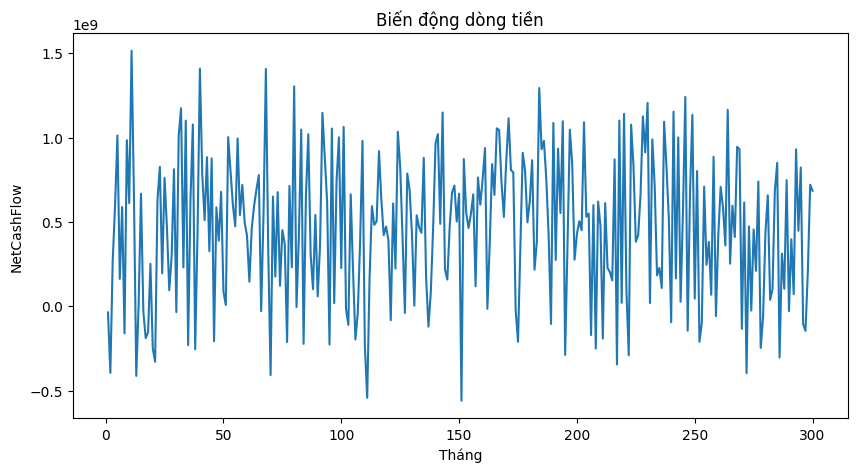

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df["Month"], df["NetCashFlow"])

plt.title("Biến động dòng tiền")
plt.xlabel("Tháng")
plt.ylabel("NetCashFlow")

plt.show()

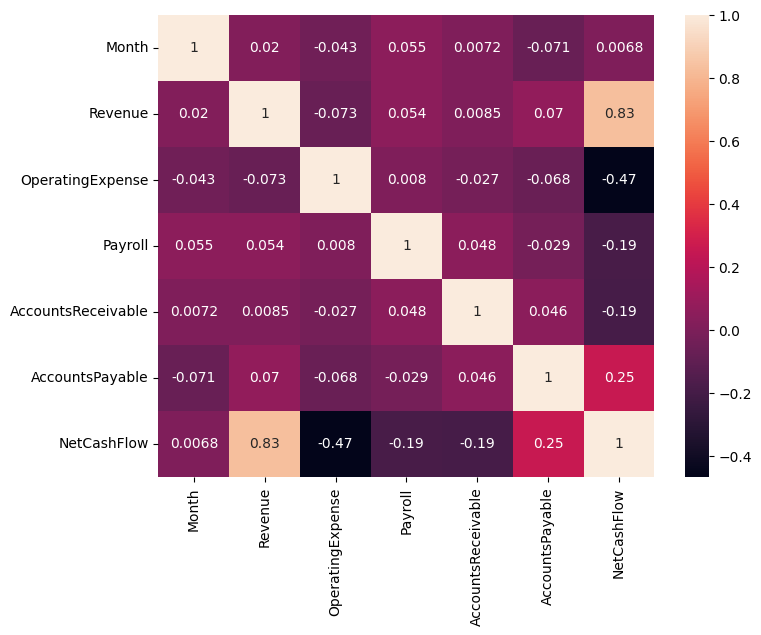

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.show()

In [ ]:
X = df[
    [
        "Revenue",
        "OperatingExpense",
        "Payroll",
        "AccountsReceivable",
        "AccountsPayable"
    ]
]

In [ ]:
y = df["NetCashFlow"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
203,531000000,4.895589e+08
266,411000000,3.963749e+08
152,557000000,6.124010e+08
9,612000000,6.155476e+08
233,184000000,1.886434e+08
226,661000000,5.387055e+08
196,1047000000,1.002818e+09
109,-237000000,-3.462682e+08
5,163000000,2.227829e+08
175,354000000,4.269242e+08


In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE =", mae)

MAE = 57605774.28193371


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("RMSE =", rmse)

RMSE = 65780063.17841749


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(
    y_test,
    y_pred
)

print("R2 =", r2)

R2 = 0.9701124580093979


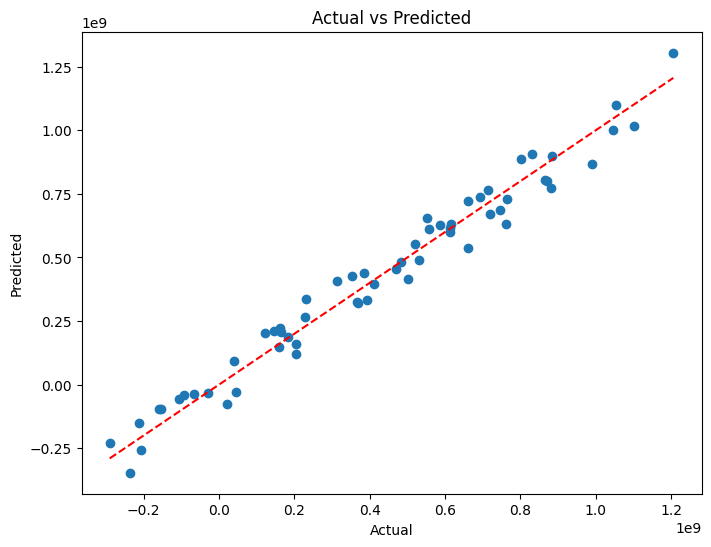

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()